In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("customer 1-EDa-prj1.csv",iterator=False)

In [3]:
df.head()

,customer_id,age,income,purchase_amount,gender,region,total_purchases,preferred_product_category,customer_loyalty_score,signup_date,last_purchase_date
0,1,56.0,67700.0,1019.145669,Female,South,31.0,Toys,12.501082,2022-05-01,2022-02-27
1,2,69.0,50200.0,252.214693,Male,North,27.0,Toys,14.402036,2022-03-14,2022-07-03
2,3,46.0,84000.0,354.742321,Male,East,25.0,Clothing,89.085761,2022-07-17,2022-04-13
3,4,32.0,42700.0,716.573913,Male,West,5.0,Electronics,98.800804,2022-07-09,2021-04-21
4,5,60.0,112300.0,1528.118235,Female,West,6.0,Clothing,28.893785,2021-04-21,2021-06-02


### removing data with invalid categories and age<0


also removing null and duplicates


In [4]:

cleaned_df = df[df['age']<=100]
#cleaned_df = cleaned_df[cleaned_df['age']>=0] # removing age data <0 and >100


In [5]:
cleaned_df.head()

,customer_id,age,income,purchase_amount,gender,region,total_purchases,preferred_product_category,customer_loyalty_score,signup_date,last_purchase_date
0,1,56.0,67700.0,1019.145669,Female,South,31.0,Toys,12.501082,2022-05-01,2022-02-27
1,2,69.0,50200.0,252.214693,Male,North,27.0,Toys,14.402036,2022-03-14,2022-07-03
2,3,46.0,84000.0,354.742321,Male,East,25.0,Clothing,89.085761,2022-07-17,2022-04-13
3,4,32.0,42700.0,716.573913,Male,West,5.0,Electronics,98.800804,2022-07-09,2021-04-21
4,5,60.0,112300.0,1528.118235,Female,West,6.0,Clothing,28.893785,2021-04-21,2021-06-02


In [6]:
cleaned_df.isna().sum()

customer_id                   0
age                           0
income                        6
purchase_amount               6
gender                        7
region                        6
total_purchases               6
preferred_product_category    8
customer_loyalty_score        5
signup_date                   6
last_purchase_date            6
dtype: int64

In [7]:
#cleaned_df = cleaned_df.dropna()
cleaned_df = cleaned_df.drop_duplicates()

In [8]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3463 entries, 0 to 3475
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 3463 non-null   int64  
 1   age                         3463 non-null   float64
 2   income                      3457 non-null   float64
 3   purchase_amount             3457 non-null   float64
 4   gender                      3456 non-null   object 
 5   region                      3457 non-null   object 
 6   total_purchases             3457 non-null   float64
 7   preferred_product_category  3455 non-null   object 
 8   customer_loyalty_score      3458 non-null   float64
 9   signup_date                 3457 non-null   object 
 10  last_purchase_date          3457 non-null   object 
dtypes: float64(5), int64(1), object(5)
memory usage: 324.7+ KB


In [9]:
cleaned_df.head()

,customer_id,age,income,purchase_amount,gender,region,total_purchases,preferred_product_category,customer_loyalty_score,signup_date,last_purchase_date
0,1,56.0,67700.0,1019.145669,Female,South,31.0,Toys,12.501082,2022-05-01,2022-02-27
1,2,69.0,50200.0,252.214693,Male,North,27.0,Toys,14.402036,2022-03-14,2022-07-03
2,3,46.0,84000.0,354.742321,Male,East,25.0,Clothing,89.085761,2022-07-17,2022-04-13
3,4,32.0,42700.0,716.573913,Male,West,5.0,Electronics,98.800804,2022-07-09,2021-04-21
4,5,60.0,112300.0,1528.118235,Female,West,6.0,Clothing,28.893785,2021-04-21,2021-06-02


In [10]:
cleaned_df = cleaned_df[
    (cleaned_df['age'] > 0) & 
    (cleaned_df['income'] > 0) & 
    (cleaned_df['total_purchases'] > 0) & 
    (cleaned_df['customer_loyalty_score'] > 0)
]

In [11]:
cleaned_df.describe()

,customer_id,age,income,purchase_amount,total_purchases,customer_loyalty_score
count,3431.000000,3431.000000,3.431000e+03,3425.000000,3431.000000,3431.000000
mean,1735.968522,48.768289,7.481483e+04,1368.959469,34.326727,62.667332
std,1004.263936,17.974916,1.934126e+05,10399.298564,266.690013,363.332367
min,1.000000,18.000000,1.000000e+00,-10000.000000,1.000000,0.000930
25%,866.500000,33.000000,4.410000e+04,515.673729,13.000000,24.277457
50%,1735.000000,49.000000,6.940000e+04,1008.389173,24.000000,49.472350
75%,2604.500000,64.000000,9.580000e+04,1496.552793,37.000000,74.503389
max,3476.000000,79.000000,9.999999e+06,500000.000000,10000.000000,15000.000000


### performing EDA on Categorical Columns


In [12]:
cat_cols = ['gender' , 'region' , 'preferred_product_category']
for col in cat_cols:
    print(col , " : ",cleaned_df[col].unique())

gender  :  ['Female' 'Male' nan 'Non-binary' 'Null' 'Unknown' '123' '0' ' ' '999'
 'Invalid' 'Alien']
region  :  ['South' 'North' 'East' 'West' 'Invalid' nan 'Unknown' 'Space' 'Void'
 'Moon' 'Pluto' '123' 'Atlantis' 'Test' 'Mars']
preferred_product_category  :  ['Toys' 'Clothing' 'Electronics' 'Home & Garden' 'Health' nan 'Test'
 'Invalid' 'Alien' 'Unknown' 'Food' 'Null' '999' 'Space']


In [13]:
invalid_gender = ['Null', 'Unknown', '123' ,'0' ,' ', '999','Invalid', 'Alien']
invalid_region = ['Invalid', 'Unknown', 'Space', 'Void', 'Moon','Pluto', '123', 'Atlantis' ,'Test', 'Mars']
invalid_category = ['Invalid','Alien', 'Unknown', 'Null', '999']


In [22]:
# Remove rows where gender is in invalid_gender OR region is in invalid_region OR category is in invalid_category
df_clean = cleaned_df[
    ~cleaned_df['gender'].isin(invalid_gender) & 
    ~cleaned_df['region'].isin(invalid_region) & 
    ~cleaned_df['preferred_product_category'].isin(invalid_category)
]

# If you want to modify the original DataFrame:
# df = df[~df['gender'].isin(invalid_gender) & ~df['region'].isin(invalid_region) & ~df['category'].isin(invalid_category)]

In [23]:
df_clean['gender'].unique()

array(['Female', 'Male', nan, 'Non-binary'], dtype=object)

In [24]:
df_clean['signup_date'] = pd.to_datetime(df_clean['signup_date'])
df_clean['last_purchase_date'] = pd.to_datetime(df_clean['last_purchase_date'])

C:\Users\HP\AppData\Local\Temp\ipykernel_40224\2020805953.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['signup_date'] = pd.to_datetime(df_clean['signup_date'])
C:\Users\HP\AppData\Local\Temp\ipykernel_40224\2020805953.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['last_purchase_date'] = pd.to_datetime(df_clean['last_purchase_date'])


In [36]:
df_clean['signup_date'].head()

0   2022-05-01
1   2022-03-14
2   2022-07-17
3   2022-07-09
4   2021-04-21
Name: signup_date, dtype: datetime64[ns]

### Bivariate analysis

In [28]:
import seaborn as sns

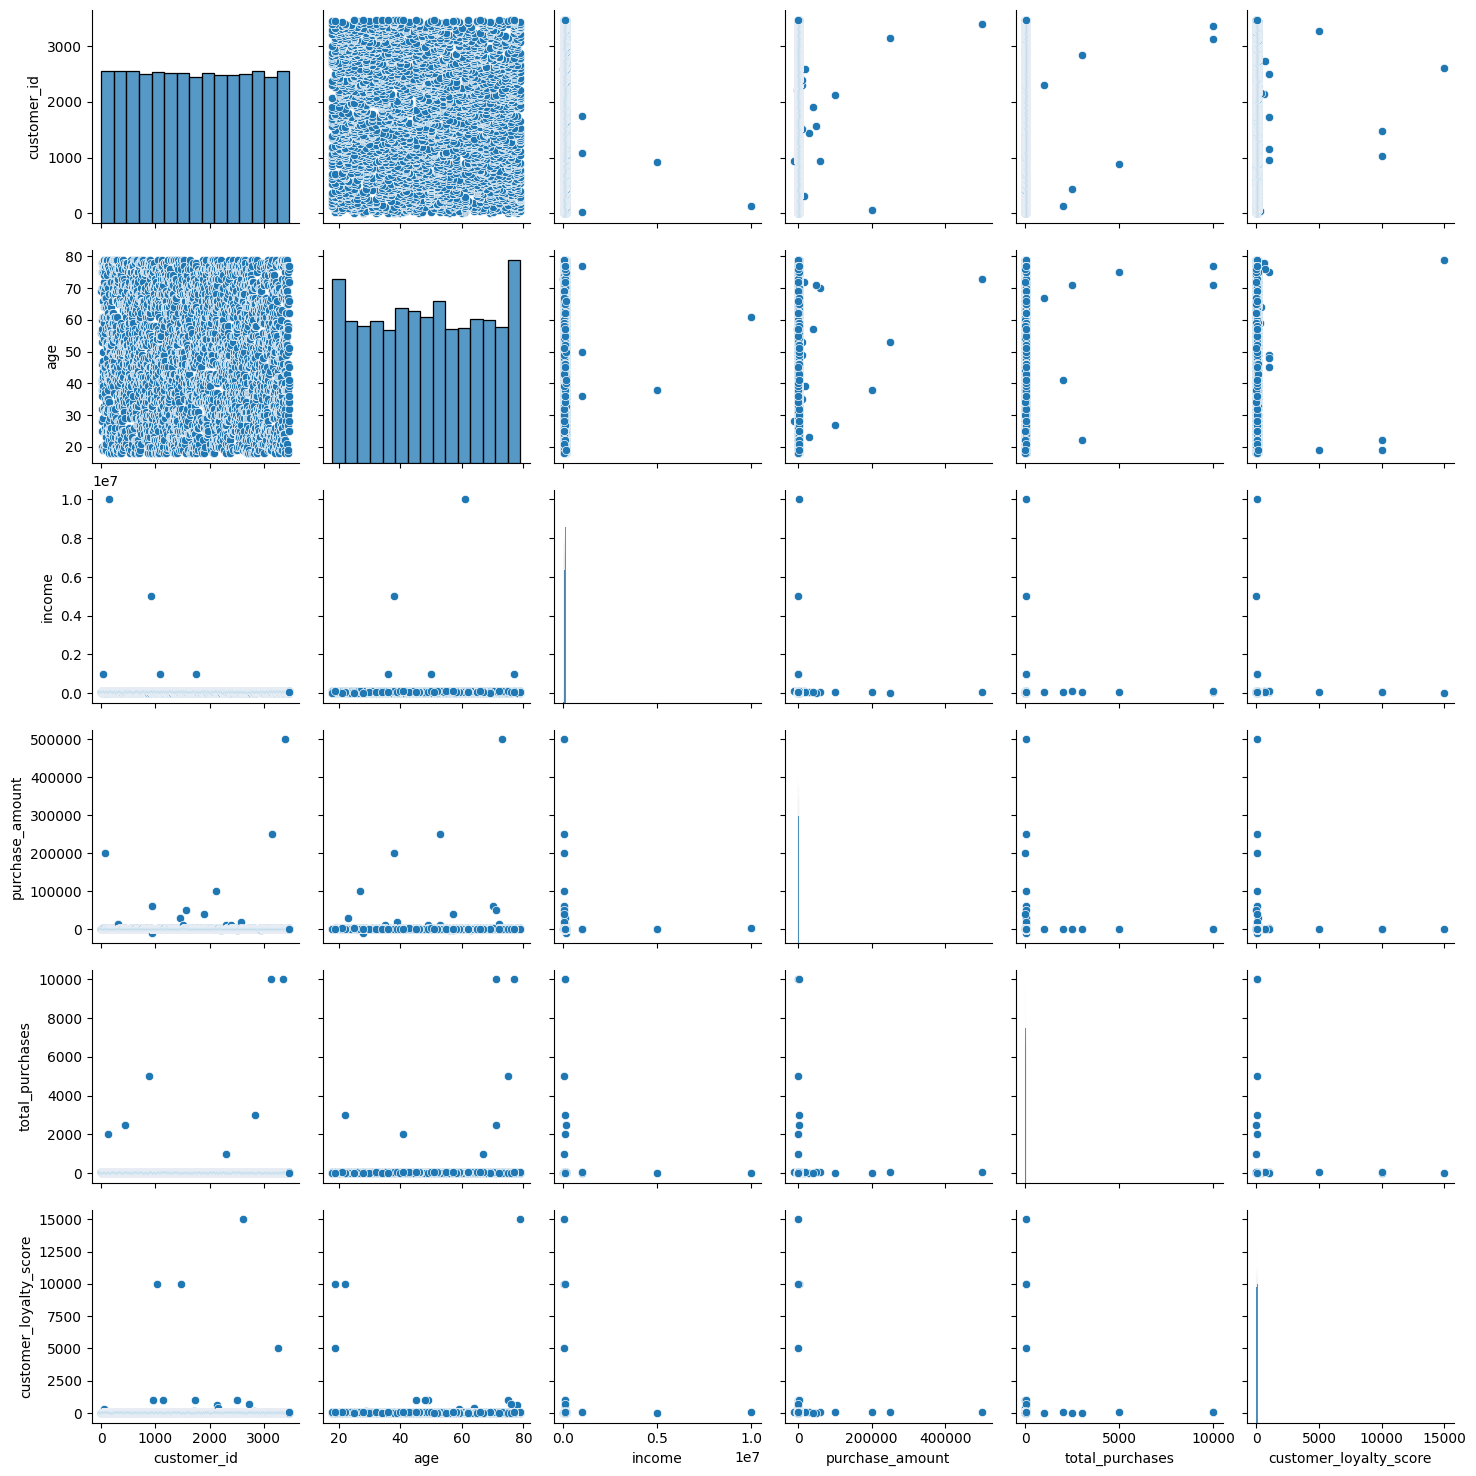

In [34]:
sns.pairplot(df_clean)

<Axes: xlabel='age', ylabel='income'>

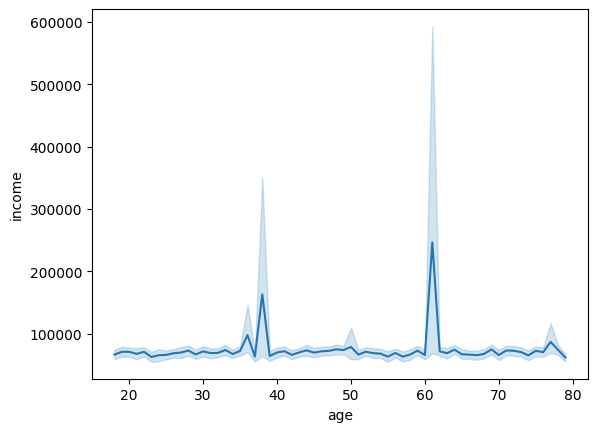

In [32]:
sns.lineplot(x=df_clean['age'] ,y=df_clean['income'])


In [ ]:
corr = df_clean[['age','income','purchase_amount','total_purchases','customer_loyalty_score']].corr()

In [33]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3408 entries, 0 to 3475
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   customer_id                 3408 non-null   int64         
 1   age                         3408 non-null   float64       
 2   income                      3408 non-null   float64       
 3   purchase_amount             3402 non-null   float64       
 4   gender                      3401 non-null   object        
 5   region                      3402 non-null   object        
 6   total_purchases             3408 non-null   float64       
 7   preferred_product_category  3402 non-null   object        
 8   customer_loyalty_score      3408 non-null   float64       
 9   signup_date                 3402 non-null   datetime64[ns]
 10  last_purchase_date          3402 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(5), int64(1), object(3)
memory 

<Axes: >

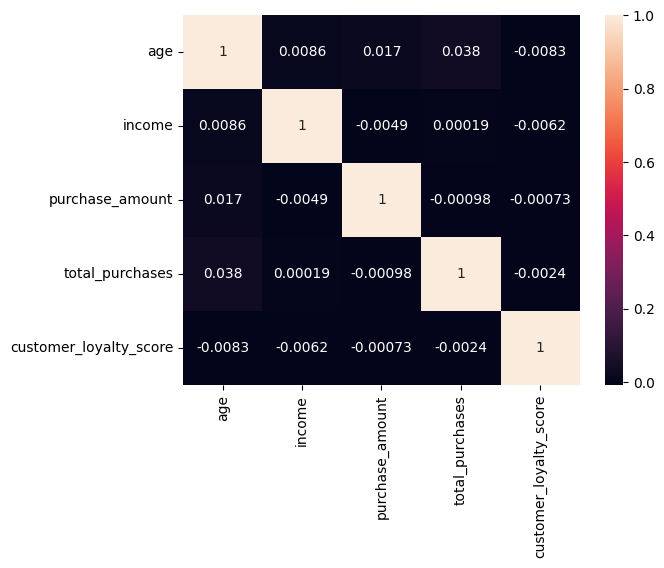

In [ ]:

sns.heatmap(corr , annot=True)

### SignUp per months

In [39]:
import matplotlib.pyplot as plt

In [37]:
monthly_signups = cleaned_df['signup_date'].dt.to_period('M').value_counts().sort_index()

# Convert to proper datetime for plotting
monthly_signups.index = monthly_signups.index.to_timestamp()

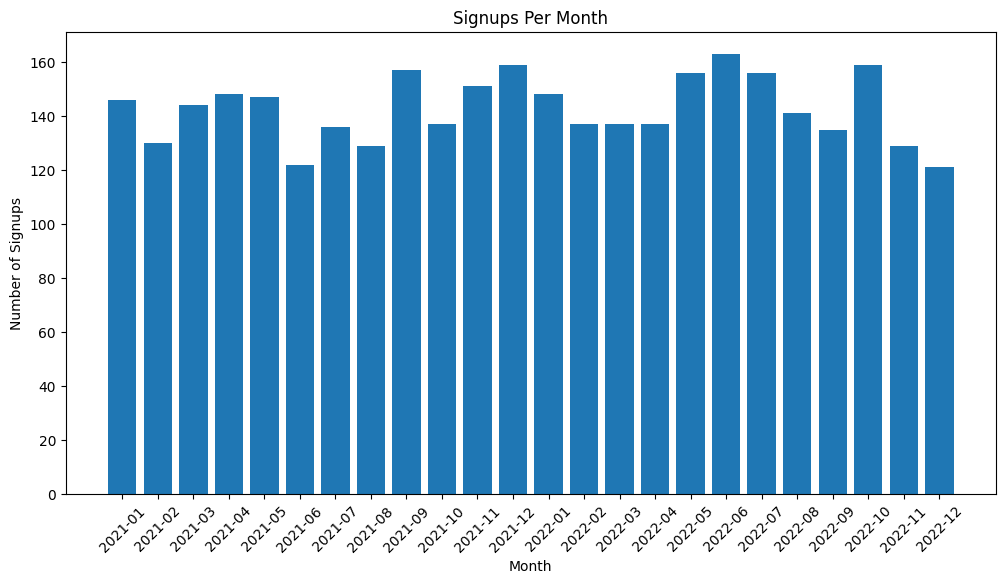

In [44]:
plt.figure(figsize=(12, 6))
plt.bar(monthly_signups.index.strftime('%Y-%m'), monthly_signups.values)
plt.title('Signups Per Month')
plt.xlabel('Month')
plt.ylabel('Number of Signups')
plt.xticks(rotation=45)

plt.show()

In [49]:
df_clean = df_clean[df_clean['last_purchase_date'] >= df_clean['signup_date']]

In [50]:
df_clean['customer_days'] = df_clean['last_purchase_date'] - df_clean['signup_date']

C:\Users\HP\AppData\Local\Temp\ipykernel_40224\3853087609.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['customer_days'] = df_clean['last_purchase_date'] - df_clean['signup_date']


In [52]:
df_clean['customer_days'].describe()

count                           2282
mean     392 days 13:56:06.520595968
std      254 days 20:04:39.015782500
min                  0 days 00:00:00
25%                186 days 00:00:00
50%                363 days 12:00:00
75%                578 days 00:00:00
max               1068 days 00:00:00
Name: customer_days, dtype: object

###  age segmentation

In [66]:
df_clean['age_segment'] = pd.cut(df_clean['age'], 
                                     bins=4, 
                                     labels=['young', 'mid', 'old', 'Very Old'])

In [53]:
df_clean['customer_segment'] = pd.cut(df_clean['customer_days'], 
                                     bins=5, 
                                     labels=['Very New', 'New', 'Regular', 'Loyal', 'Very Old'])

C:\Users\HP\AppData\Local\Temp\ipykernel_40224\376178398.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['customer_segment'] = pd.cut(df_clean['customer_days'],


C:\Users\HP\AppData\Local\Temp\ipykernel_40224\3625683426.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_purchases = df_clean.groupby('customer_segment')['purchase_amount'].sum().sort_index()


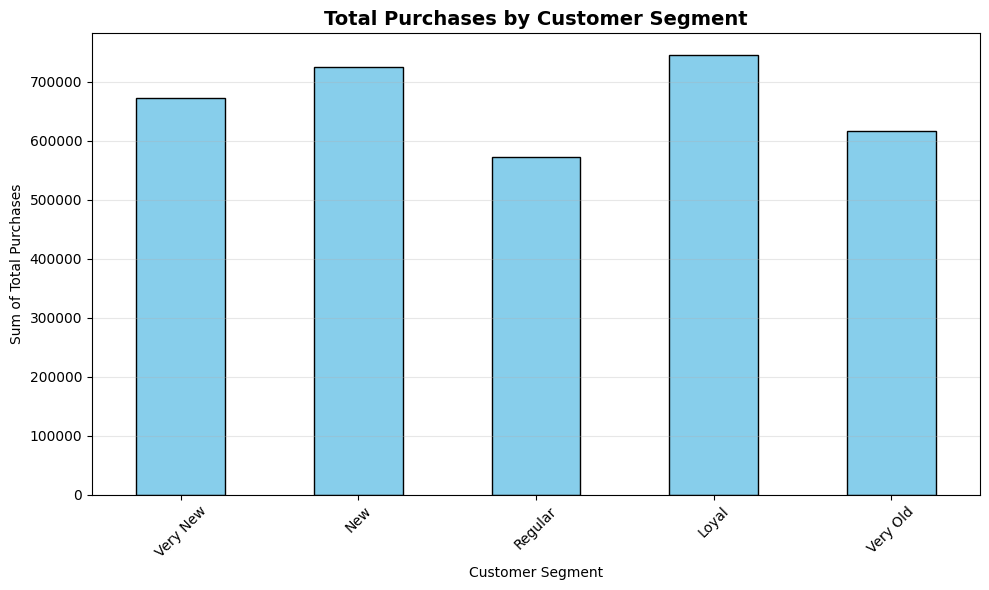

In [54]:
segment_purchases = df_clean.groupby('customer_segment')['purchase_amount'].sum().sort_index()

# Plot
plt.figure(figsize=(10, 6))
segment_purchases.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total Purchases by Customer Segment', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment')
plt.ylabel('Sum of Total Purchases')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

(array([0, 1, 2]),
 [Text(0, 0, 'Female'), Text(1, 0, 'Male'), Text(2, 0, 'Non-binary')])

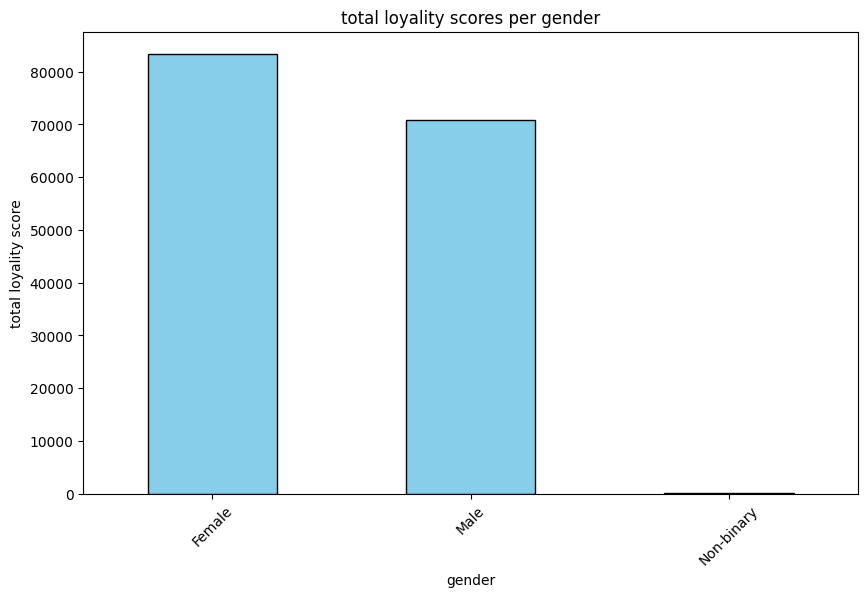

In [56]:
segment_purchases = df_clean.groupby('gender')['customer_loyalty_score'].sum().sort_index()

# Plot
plt.figure(figsize=(10, 6))
segment_purchases.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('total loyality scores per gender')
plt.xlabel('gender')
plt.ylabel('total loyality score')
plt.xticks(rotation=45)

In [88]:
df_clean.to_csv('DataAfterEDA.csv')

In [68]:
df_clean['region'].unique()

array(['North', 'West', 'East', 'South'], dtype=object)

In [89]:
df_clean.isna().sum()

customer_id                     0
age                             0
income                          0
purchase_amount                 0
gender                          0
region                          0
total_purchases                 0
preferred_product_category      0
customer_loyalty_score          0
signup_date                     0
last_purchase_date              0
customer_days                   0
customer_segment                0
age_segment                     0
clv_segment                   538
dtype: int64

In [71]:
df_clean.describe()

,customer_id,age,income,purchase_amount,total_purchases,customer_loyalty_score,signup_date,last_purchase_date,customer_days
count,2264.000000,2264.000000,2.264000e+03,2264.000000,2264.000000,2264.000000,2264,2264,2264
mean,1746.473940,48.379859,7.328852e+04,1463.294992,36.253092,67.851529,2021-11-03 11:56:49.187279104,2022-12-01 16:06:08.904593664,393 days 04:09:19.717314488
min,2.000000,18.000000,2.020000e+04,-10000.000000,1.000000,0.085729,2021-01-01 00:00:00,2021-01-21 00:00:00,0 days 00:00:00
25%,878.750000,33.000000,4.487500e+04,526.563855,13.000000,24.648026,2021-05-09 18:00:00,2022-06-05 18:00:00,186 days 00:00:00
50%,1745.000000,48.000000,7.010000e+04,1008.312158,24.000000,50.484010,2021-10-13 00:00:00,2022-12-30 00:00:00,364 days 00:00:00
75%,2631.250000,64.000000,9.630000e+04,1498.587647,37.000000,74.935626,2022-04-14 00:00:00,2023-07-05 00:00:00,578 days 00:00:00
max,3475.000000,79.000000,5.000000e+06,500000.000000,10000.000000,15000.000000,2022-12-31 00:00:00,2023-12-31 00:00:00,1068 days 00:00:00
std,1005.934411,17.767379,1.110367e+05,12508.498182,308.288740,434.448533,NaN,NaN,254 days 20:39:17.703108828


In [86]:
df_clean.drop(columns=['clv_segment'] , axis=1)

,customer_id,age,income,purchase_amount,gender,region,total_purchases,preferred_product_category,customer_loyalty_score,signup_date,last_purchase_date,customer_days,customer_segment,age_segment
1,2,69.0,50200.0,252.214693,Male,North,27.0,Toys,14.402036,2022-03-14,2022-07-03,111 days,Very New,Very Old
4,5,60.0,112300.0,1528.118235,Female,West,6.0,Clothing,28.893785,2021-04-21,2021-06-02,42 days,Very New,old
5,6,25.0,62000.0,1024.023200,Male,West,5.0,Home & Garden,14.360273,2021-11-18,2023-07-06,595 days,Regular,young
6,7,78.0,90500.0,1283.045712,Female,East,27.0,Home & Garden,48.221228,2022-06-11,2023-02-01,235 days,New,Very Old
7,8,38.0,81000.0,1970.645619,Male,East,8.0,Clothing,70.952806,2021-06-26,2022-12-21,543 days,Regular,mid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3466,3467,39.0,43200.0,1022.574095,Female,North,34.0,Toys,13.352897,2022-03-21,2022-09-04,167 days,Very New,mid
3467,3468,25.0,23800.0,1943.602386,Male,West,4.0,Health,23.179639,2022-03-29,2022-12-23,269 days,New,young
3470,3471,34.0,80400.0,465.975007,Male,South,3.0,Electronics,13.268861,2021-03-07,2023-07-29,874 days,Very Old,mid
3471,3472,77.0,64400.0,1369.291029,Female,South,35.0,Home & Garden,73.795857,2022-02-09,2023-09-05,573 days,Regular,Very Old


In [87]:
# Segment customers by CLV (total_purchase_amount)
clv_segments = pd.cut(df_clean['purchase_amount'], 
                     bins=[500, 1000, 1500,3000, float('inf')],
                     labels=['Low', 'Medium','High', 'VIP'])

df_clean['clv_segment'] = clv_segments